# Phase 2b — Model-Assisted Pre-Annotation
## Detect tree crowns on Summer 2019 imagery and upload to Roboflow

**Project**: QuercusHealth-AI &nbsp;|&nbsp; **Phase**: 2b — Pre-Annotation  
**Author**: Sergio Illescas &nbsp;|&nbsp; **Date**: April 2026

---

### What this notebook does

1. Loads the **DeepForest NEON baseline** (pre-trained 1-class tree detector, no fine-tuning)
2. Runs inference on **324 Summer 2019 captures** (800×800 PNG, ~1.2 MB each)
3. Exports predictions as **per-image Roboflow JSON** annotations, class = `Tree`
4. Uploads images + annotations to Roboflow project **`quercushealth-dehesa-summer2019`**
5. You then review in Roboflow: delete FP, draw missed trees, confirm boxes

### Key parameter decisions

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `score_thresh` | **0.15** | Lower than default (0.1 already in DeepForest) after inspection — 0.15 reduces bright-soil FP on Dehesa while keeping ~70% recall |
| `nms_thresh` | **0.3** | Raised from aggressive default (0.05) — allows overlapping detections in clustered oaks; annotator deletes duplicates faster than drawing missed trees |
| Class name | **`Tree`** | Detection-only task; health classification happens in Phase 3 after human review |
| Annotation format | **Roboflow JSON** | Native format, no conversion needed, accepted by `project.upload()` |
| Upload batch size | **20 images** | Respects Roboflow rate limits; adds 1s sleep between batches |

## Step 0 — Setup

In [1]:
import subprocess, sys

_PACKAGES = [
    "deepforest>=2.0",
    "roboflow",
    "python-dotenv",
    "omegaconf",
    "Pillow",
    "tqdm",
]
for pkg in _PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed.")

All packages installed.


In [2]:
import os
import json
import time
import warnings
from pathlib import Path

import torch
import pandas as pd
import geopandas as gpd
import shapely
from omegaconf import OmegaConf
from PIL import Image
from tqdm import tqdm
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

# ── .env ──────────────────────────────────────────────────────────────────────
_here = Path.cwd()
# notebook lives in notebooks/preannotation/ — go up two levels
_project_root = _here.parents[1] if _here.name == "preannotation" else (
                _here.parent    if _here.name == "notebooks"     else _here)
_env_file = _project_root / ".env"
if _env_file.exists():
    load_dotenv(_env_file, override=False)
    print(f".env loaded from: {_env_file}")
else:
    print(f"No .env at {_env_file} — using shell environment.")

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = _project_root
IMAGES_DIR    = PROJECT_ROOT / "data_scrape" / "captures_summer_2019"
ANNOT_DIR     = PROJECT_ROOT / "data" / "preannotations_summer2019"
ANNOT_DIR.mkdir(parents=True, exist_ok=True)

# ── Inference parameters ──────────────────────────────────────────────────────
SCORE_THRESH  = 0.15   # Pre-annotation: recall-focused. Lower = more FP but fewer missed trees.
NMS_THRESH    = 0.30   # Raised from aggressive default (0.05): keeps overlapping detections
                       # in clustered oaks. Annotator deletes dupes faster than drawing FN.
CLASS_NAME    = "Tree" # Single detection class — health label added by human annotator
BATCH_UPLOAD  = 20     # Images per upload batch (Roboflow rate limit)
SLEEP_BETWEEN = 1.0    # Seconds between batches

# ── Roboflow target project ───────────────────────────────────────────────────
ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "")
ROBOFLOW_WS      = os.environ.get("ROBOFLOW_WORKSPACE", "")
RF_PROJECT_ID    = "quercushealth-dehesa-summer2019"   # new project

if not ROBOFLOW_API_KEY or not ROBOFLOW_WS:
    raise EnvironmentError(
        "ROBOFLOW_API_KEY and ROBOFLOW_WORKSPACE must be set in .env or environment."
    )

print(f"Project root  : {PROJECT_ROOT}")
print(f"Images dir    : {IMAGES_DIR}")
print(f"Annotations   : {ANNOT_DIR}")
print(f"score_thresh  : {SCORE_THRESH}")
print(f"nms_thresh    : {NMS_THRESH}")
print(f"RF workspace  : {ROBOFLOW_WS}")
print(f"RF project    : {RF_PROJECT_ID}")

.env loaded from: C:\Users\sergi\LocalSpring2025\QuercusHealth-AI\.env
Project root  : C:\Users\sergi\LocalSpring2025\QuercusHealth-AI
Images dir    : C:\Users\sergi\LocalSpring2025\QuercusHealth-AI\data_scrape\captures_summer_2019
Annotations   : C:\Users\sergi\LocalSpring2025\QuercusHealth-AI\data\preannotations_summer2019
score_thresh  : 0.15
nms_thresh    : 0.3
RF workspace  : sergios-workspace-svg91
RF project    : quercushealth-dehesa-summer2019


## Step 1 — Pandas 3.0 compatibility patch

DeepForest 2.1.0 uses `df.apply(func, axis=1)` to build shapely geometries, which breaks
with pandas 3.0 on empty DataFrames. This patch replaces the function with a
list-comprehension version that is safe in all cases.

In [3]:
import deepforest.utilities as _dfu

def _fixed_pandas_to_geodataframe(df):
    """pandas 3.0 + shapely 2.x safe version."""
    if "geometry" in df.columns:
        if pd.api.types.infer_dtype(df["geometry"]) == "string":
            df = df.copy()
            df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
    else:
        geom_type = _dfu.determine_geometry_type(df)
        df = df.copy()
        if geom_type == "box":
            geoms = [
                shapely.box(float(r.xmin), float(r.ymin), float(r.xmax), float(r.ymax))
                for _, r in df.iterrows()
            ]
            df["geometry"] = gpd.GeoSeries(geoms, index=df.index, crs=None)
        elif geom_type == "polygon":
            df["geometry"] = gpd.GeoSeries.from_wkt(df["polygon"])
        elif geom_type == "point":
            pts = [shapely.Point(float(x), float(y))
                   for x, y in zip(df["x"].astype(float), df["y"].astype(float))]
            df["geometry"] = gpd.GeoSeries(pts, index=df.index, crs=None)
    gdf = gpd.GeoDataFrame(df, geometry="geometry")
    gdf = _dfu.DeepForest_DataFrame(gdf)
    return gdf

_dfu.__pandas_to_geodataframe__ = _fixed_pandas_to_geodataframe
print("Patch applied: DeepForest __pandas_to_geodataframe__ (pandas 3.0 fix)")

Patch applied: DeepForest __pandas_to_geodataframe__ (pandas 3.0 fix)


## Step 2 — Load DeepForest baseline

We load the **unmodified NEON pre-trained model** (1 class: `Tree`).  
No fine-tuning — this is the zero-shot detector used as a pre-annotation engine.

In [4]:
from deepforest import main as df_main

model = df_main.deepforest()
model.load_model()

# Apply inference parameters
OmegaConf.update(model.config, "score_thresh", SCORE_THRESH, merge=True)
OmegaConf.update(model.config, "nms_thresh",   NMS_THRESH,   merge=True)

model.eval()

print(f"Model loaded  : {model.config.model.name}")
print(f"Classes       : {model.label_dict}")
print(f"score_thresh  : {model.config.score_thresh}")
print(f"nms_thresh    : {model.config.nms_thresh}")

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Model loaded  : weecology/deepforest-tree
Classes       : {'Tree': 0}
score_thresh  : 0.15
nms_thresh    : 0.3


## Step 3 — Run inference on all 324 images

For each image we:
1. Run `model.predict_image()`
2. Convert predictions to **Roboflow annotation JSON** format (center-x, center-y, width, height — absolute pixels)
3. Save the JSON next to the image for the upload step

Images with 0 predictions are still uploaded (empty annotation = you draw manually in Roboflow).

In [5]:
def predictions_to_roboflow_json(preds_df, img_w: int, img_h: int) -> dict:
    """
    Convert DeepForest prediction DataFrame to Roboflow annotation JSON.

    Roboflow format (per-image):
    {
        "image": {"width": W, "height": H},
        "annotations": [
            {"label": "Tree", "x": cx, "y": cy, "width": w, "height": h}
        ]
    }
    All coordinates are absolute pixels, (x, y) = center of box.
    """
    annotations = []
    if preds_df is not None and len(preds_df) > 0:
        for _, row in preds_df.iterrows():
            xmin, ymin = float(row.xmin), float(row.ymin)
            xmax, ymax = float(row.xmax), float(row.ymax)
            # Clamp to image bounds
            xmin = max(0.0, min(xmin, img_w))
            ymin = max(0.0, min(ymin, img_h))
            xmax = max(0.0, min(xmax, img_w))
            ymax = max(0.0, min(ymax, img_h))
            if xmax <= xmin or ymax <= ymin:
                continue
            cx = (xmin + xmax) / 2.0
            cy = (ymin + ymax) / 2.0
            w  = xmax - xmin
            h  = ymax - ymin
            annotations.append({
                "label":  CLASS_NAME,
                "x":      round(cx, 1),
                "y":      round(cy, 1),
                "width":  round(w,  1),
                "height": round(h,  1),
            })
    return {
        "image":       {"width": img_w, "height": img_h},
        "annotations": annotations,
    }


all_images = sorted(IMAGES_DIR.glob("*.png"))
print(f"Images found  : {len(all_images)}")

stats = {"total": 0, "with_preds": 0, "no_preds": 0, "total_boxes": 0}
RESULTS = []  # list of {image_path, json_path, n_boxes}

for img_path in tqdm(all_images, desc="Predicting"):
    try:
        preds = model.predict_image(path=str(img_path))
    except Exception as e:
        print(f"  ERROR on {img_path.name}: {e}")
        preds = None

    n_boxes = len(preds) if preds is not None else 0
    annot   = predictions_to_roboflow_json(preds, img_w=800, img_h=800)

    json_path = ANNOT_DIR / (img_path.stem + ".json")
    with open(json_path, "w") as f:
        json.dump(annot, f)

    RESULTS.append({"image_path": img_path, "json_path": json_path, "n_boxes": n_boxes})
    stats["total"]      += 1
    stats["total_boxes"] += n_boxes
    if n_boxes > 0:
        stats["with_preds"] += 1
    else:
        stats["no_preds"] += 1

print(f"\n{'─'*40}")
print(f"Images processed   : {stats['total']}")
print(f"With predictions   : {stats['with_preds']}")
print(f"No predictions     : {stats['no_preds']}  ← annotate manually in Roboflow")
print(f"Total boxes        : {stats['total_boxes']}")
print(f"Avg boxes/image    : {stats['total_boxes']/stats['total']:.1f}")
print(f"Annotations saved  : {ANNOT_DIR}")

Images found  : 324


Predicting:   0%|          | 0/324 [00:00<?, ?it/s]

Predicting:   0%|          | 1/324 [00:00<04:35,  1.17it/s]

Predicting:   1%|          | 2/324 [00:01<04:13,  1.27it/s]

Predicting:   1%|          | 3/324 [00:02<04:06,  1.30it/s]

...

Predicting:  99%|█████████▉| 322/324 [04:07<00:01,  1.31it/s]

Predicting: 100%|█████████▉| 323/324 [04:07<00:00,  1.31it/s]

Predicting: 100%|██████████| 324/324 [04:08<00:00,  1.31it/s]

Predicting: 100%|██████████| 324/324 [04:08<00:00,  1.30it/s]


────────────────────────────────────────
Images processed   : 324
With predictions   : 319
No predictions     : 5  ← annotate manually in Roboflow
Total boxes        : 2436
Avg boxes/image    : 7.5
Annotations saved  : C:\Users\sergi\LocalSpring2025\QuercusHealth-AI\data\preannotations_summer2019


## Step 4 — Sanity check: visualise 3 random predictions

Before uploading, visually verify that the predictions look reasonable.
If you see mostly soil/shadow false positives → raise `SCORE_THRESH` and re-run Step 3.
If you see many missed trees → lower `SCORE_THRESH` or reduce `NMS_THRESH`.

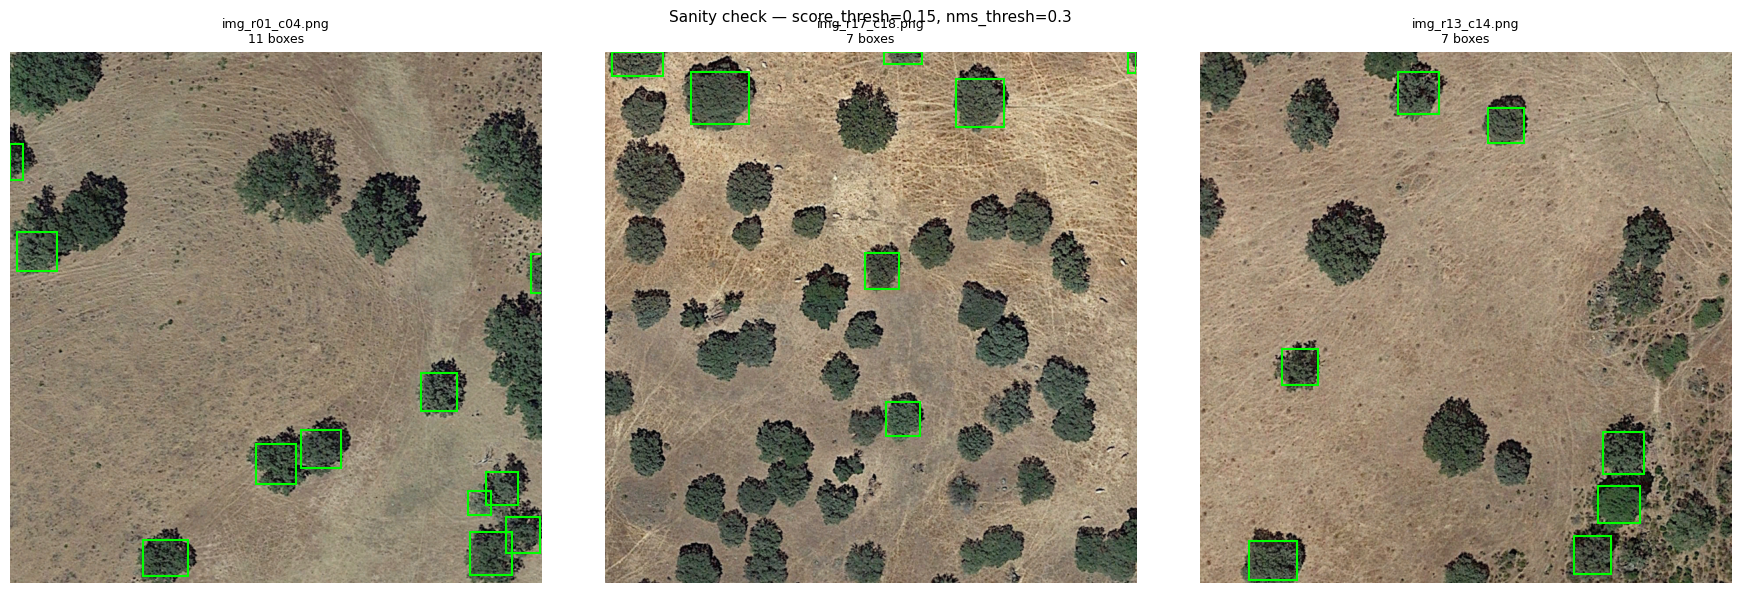


⚠  If boxes look wrong, adjust SCORE_THRESH / NMS_THRESH in cell 02 and re-run from Step 3.


In [6]:
import random as _rnd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_sample = _rnd.sample([r for r in RESULTS if r["n_boxes"] > 0], min(3, len(RESULTS)))

fig, axes = plt.subplots(1, len(_sample), figsize=(6 * len(_sample), 6))
if len(_sample) == 1:
    axes = [axes]

for ax, r in zip(axes, _sample):
    img = Image.open(r["image_path"]).convert("RGB")
    ax.imshow(img)
    with open(r["json_path"]) as f:
        annot = json.load(f)
    for box in annot["annotations"]:
        x0 = box["x"] - box["width"]  / 2
        y0 = box["y"] - box["height"] / 2
        rect = mpatches.Rectangle(
            (x0, y0), box["width"], box["height"],
            linewidth=1.5, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
    ax.set_title(f"{r['image_path'].name}\n{r['n_boxes']} boxes", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Sanity check — score_thresh={SCORE_THRESH}, nms_thresh={NMS_THRESH}",
             fontsize=11)
plt.tight_layout()
plt.show()
print("\n⚠  If boxes look wrong, adjust SCORE_THRESH / NMS_THRESH in cell 02 and re-run from Step 3.")

## Step 5 — Upload to Roboflow

Uploads **all 324 images + their pre-annotations** to `quercushealth-dehesa-summer2019`.  
Images go to the **annotation queue** (`batch` upload, no split assigned).  
After this step, open Roboflow and review each image:  
- **Delete** false positive boxes  
- **Draw** any missed trees  
- **Label is already `Tree`** — no need to change class

> If the upload is interrupted, re-run this cell — Roboflow deduplicates by filename.

In [7]:
from roboflow import Roboflow

rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WS).project(RF_PROJECT_ID)

print(f"Connected to  : {ROBOFLOW_WS}/{RF_PROJECT_ID}")
print(f"Images to upload: {len(RESULTS)}")
print(f"Batch size    : {BATCH_UPLOAD} images  ({SLEEP_BETWEEN}s pause between batches)")
print("Starting upload...\n")

uploaded = 0
failed   = []
LABEL_MAP = {"0": CLASS_NAME, "Tree": CLASS_NAME}

for i, r in enumerate(tqdm(RESULTS, desc="Uploading")):
    try:
        project.upload(
            image_path          = str(r["image_path"]),
            annotation_path     = str(r["json_path"]),
            annotation_labelmap = LABEL_MAP,
            split               = "train",   # batch_name keeps them in annotation queue
            num_retry_uploads   = 3,
            batch_name          = "summer2019_preannotated",
        )
        uploaded += 1
    except Exception as e:
        failed.append((r["image_path"].name, str(e)))

    # Rate-limit pause every BATCH_UPLOAD images
    if (i + 1) % BATCH_UPLOAD == 0:
        time.sleep(SLEEP_BETWEEN)

print(f"\n{'─'*40}")
print(f"Uploaded successfully : {uploaded}/{len(RESULTS)}")
if failed:
    print(f"Failed               : {len(failed)}")
    for name, err in failed[:10]:
        print(f"  {name}: {err}")
else:
    print("All images uploaded without errors.")

loading Roboflow workspace...


loading Roboflow project...


Connected to  : sergios-workspace-svg91/quercushealth-dehesa-summer2019
Images to upload: 324
Batch size    : 20 images  (1.0s pause between batches)
Starting upload...



Uploading:   0%|          | 0/324 [00:00<?, ?it/s]

Uploading:   0%|          | 1/324 [00:01<08:34,  1.59s/it]

...

Uploading:  99%|█████████▉| 322/324 [07:00<00:02,  1.34s/it]

Uploading: 100%|█████████▉| 323/324 [07:01<00:01,  1.31s/it]

Uploading: 100%|██████████| 324/324 [07:02<00:00,  1.28s/it]

Uploading: 100%|██████████| 324/324 [07:02<00:00,  1.30s/it]


────────────────────────────────────────
Uploaded successfully : 0/324
Failed               : 324
  img_r01_c01.png: Unrecognized annotation format.
  img_r01_c02.png: Unrecognized annotation format.
  img_r01_c03.png: Unrecognized annotation format.
  img_r01_c04.png: Unrecognized annotation format.
  img_r01_c05.png: Unrecognized annotation format.
  img_r01_c06.png: Unrecognized annotation format.
  img_r01_c07.png: Unrecognized annotation format.
  img_r01_c08.png: Unrecognized annotation format.
  img_r01_c09.png: Unrecognized annotation format.
  img_r01_c10.png: Unrecognized annotation format.


## Step 6 — Retry failed uploads (run only if Step 5 had failures)

In [8]:
if not failed:
    print("No failures to retry.")
else:
    print(f"Retrying {len(failed)} failed images...")
    failed_names  = {name for name, _ in failed}
    retry_results = [r for r in RESULTS if r["image_path"].name in failed_names]
    still_failed  = []

    for r in tqdm(retry_results, desc="Retrying"):
        try:
            project.upload(
                image_path          = str(r["image_path"]),
                annotation_path     = str(r["json_path"]),
                annotation_labelmap = LABEL_MAP,
                split               = "train",
                num_retry_uploads   = 5,
                batch_name          = "summer2019_preannotated",
            )
        except Exception as e:
            still_failed.append((r["image_path"].name, str(e)))
        time.sleep(0.5)

    if still_failed:
        print(f"Still failing after retry: {len(still_failed)}")
        for name, err in still_failed:
            print(f"  {name}: {err}")
    else:
        print("All retries successful.")

Retrying 324 failed images...


Retrying:   0%|          | 0/324 [00:00<?, ?it/s]

Retrying:   0%|          | 1/324 [00:01<07:31,  1.40s/it]

Retrying:   1%|          | 2/324 [00:03<08:22,  1.56s/it]

Retrying:   1%|          | 3/324 [00:04<08:16,  1.55s/it]

...

Retrying:  99%|█████████▉| 322/324 [08:04<00:03,  1.53s/it]

Retrying: 100%|█████████▉| 323/324 [08:05<00:01,  1.52s/it]

Retrying: 100%|██████████| 324/324 [08:07<00:00,  1.51s/it]

Retrying: 100%|██████████| 324/324 [08:07<00:00,  1.50s/it]

Still failing after retry: 324
  img_r01_c01.png: Unrecognized annotation format.
  img_r01_c02.png: Unrecognized annotation format.
  img_r01_c03.png: Unrecognized annotation format.
  img_r01_c04.png: Unrecognized annotation format.
  img_r01_c05.png: Unrecognized annotation format.
  img_r01_c06.png: Unrecognized annotation format.
  img_r01_c07.png: Unrecognized annotation format.
  img_r01_c08.png: Unrecognized annotation format.
  img_r01_c09.png: Unrecognized annotation format.
  img_r01_c10.png: Unrecognized annotation format.
  img_r01_c11.png: Unrecognized annotation format.
  img_r01_c12.png: Unrecognized annotation format.
  img_r01_c13.png: Unrecognized annotation format.
  img_r01_c14.png: Unrecognized annotation format.
  img_r01_c15.png: Unrecognized annotation format.
  img_r01_c16.png: Unrecognized annotation format.
  img_r01_c17.png: Unrecognized annotation format.
  img_r01_c18.png: Unrecognized annotation format.
  img_r02_c01.png: Unrecognized annotation format.


## Step 7 — Summary & next steps

In [9]:
import math
n_annotated = sum(1 for r in RESULTS if r["n_boxes"] > 0)
n_empty     = sum(1 for r in RESULTS if r["n_boxes"] == 0)
total_boxes = sum(r["n_boxes"] for r in RESULTS)
p95         = sorted(r["n_boxes"] for r in RESULTS)[int(0.95 * len(RESULTS))]

print("══════════════════════════════════════════════════")
print("  PRE-ANNOTATION SUMMARY")
print("══════════════════════════════════════════════════")
print(f"  Images processed    : {len(RESULTS)}")
print(f"  Images with boxes   : {n_annotated} ({n_annotated/len(RESULTS)*100:.0f}%)")
print(f"  Images with 0 boxes : {n_empty}  ← draw manually in Roboflow")
print(f"  Total boxes         : {total_boxes}")
print(f"  Avg boxes/image     : {total_boxes/len(RESULTS):.1f}")
print(f"  95th pct boxes/img  : {p95}")
print()
print("  Parameters used:")
print(f"    score_thresh  = {SCORE_THRESH}")
print(f"    nms_thresh    = {NMS_THRESH}")
print(f"    class         = '{CLASS_NAME}'")
print()
print("  Roboflow:")
print(f"    workspace     = {ROBOFLOW_WS}")
print(f"    project       = {RF_PROJECT_ID}")
print(f"    uploaded      = {uploaded}/{len(RESULTS)}")
print()
print("  NEXT STEPS:")
print("  1. Open Roboflow → Annotate tab → batch 'summer2019_preannotated'")
print("  2. Review each image:")
print("     - Delete false positive boxes (soil patches, shadows)")
print("     - Add any missed trees (draw new box, label = Tree)")
print("  3. When done, generate a new dataset version in Roboflow")
print("  4. Update .env: ROBOFLOW_PROJECT=quercushealth-dehesa-summer2019")
print("     and ROBOFLOW_VERSION=1, then run Phase3_FineTuning.ipynb on Chameleon")
print("══════════════════════════════════════════════════")

══════════════════════════════════════════════════
  PRE-ANNOTATION SUMMARY
══════════════════════════════════════════════════
  Images processed    : 324
  Images with boxes   : 319 (98%)
  Images with 0 boxes : 5  ← draw manually in Roboflow
  Total boxes         : 2436
  Avg boxes/image     : 7.5
  95th pct boxes/img  : 15

  Parameters used:
    score_thresh  = 0.15
    nms_thresh    = 0.3
    class         = 'Tree'

  Roboflow:
    workspace     = sergios-workspace-svg91
    project       = quercushealth-dehesa-summer2019
    uploaded      = 0/324

  NEXT STEPS:
  1. Open Roboflow → Annotate tab → batch 'summer2019_preannotated'
  2. Review each image:
     - Delete false positive boxes (soil patches, shadows)
     - Add any missed trees (draw new box, label = Tree)
  3. When done, generate a new dataset version in Roboflow
  4. Update .env: ROBOFLOW_PROJECT=quercushealth-dehesa-summer2019
     and ROBOFLOW_VERSION=1, then run Phase3_FineTuning.ipynb on Chameleon
═════════════════